In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## Volunteer Segments

We will start this segment analysis on the subset of the processed data that is identified as volunteers.

In [2]:
df = pd.read_csv('../data/processed/cev_volunteers.csv')

In [3]:
df.head()

,hrnumhou,supwgt,hubus_YES,gtmetsta_NONMETROPOLITAN,pesex_MALE,veteran_Yes,pehspnon_NON-HISPANIC,disability_Yes,action_Yes,meeting_Yes,...,citizen_type_Citizen,citizen_type_Naturalized,citizen_type_Non,work_status_Employed,work_status_Not Working,work_status_Unemployed,housing_unit_House,housing_unit_Mobile,housing_unit_Other,housing_unit_Unit
0,2,2743.1032,0,0,0,0,1,0,0,0,...,1,0,0,0,1,0,1,0,0,0
1,5,3734.6711,0,0,1,0,1,0,0,0,...,1,0,0,1,0,0,1,0,0,0
2,5,3619.4642,0,0,0,0,1,0,0,0,...,1,0,0,1,0,0,1,0,0,0
3,4,3063.2525,0,0,1,0,1,0,1,0,...,1,0,0,1,0,0,1,0,0,0
4,4,3411.9942,0,0,0,0,1,0,1,0,...,1,0,0,0,1,0,1,0,0,0


In [4]:
df.columns

Index(['hrnumhou', 'supwgt', 'hubus_YES', 'gtmetsta_NONMETROPOLITAN',
       'pesex_MALE', 'veteran_Yes', 'pehspnon_NON-HISPANIC', 'disability_Yes',
       'action_Yes', 'meeting_Yes', 'contact_Yes', 'boycott_Yes', 'org_Yes',
       'politicaldonor_Yes', 'donate_Yes', 'fftalk_encoded',
       'ffissues_encoded', 'ntalk_encoded', 'nissues_encoded',
       'favors_encoded', 'views_encoded', 'news_encoded', 'ed_level_encoded',
       'age_encoded', 'hhincome_encoded', 'hetenure_Free', 'hetenure_Owned',
       'hetenure_Rented', 'gereg_MIDWEST', 'gereg_NORTHEAST', 'gereg_SOUTH',
       'gereg_WEST', 'pemaritl_DIVORCED', 'pemaritl_MARRIED',
       'pemaritl_NEVER MARRIED', 'pemaritl_SEPARATED', 'pemaritl_WIDOWED',
       'voterstatus_NA', 'voterstatus_No', 'voterstatus_Yes', 'simrace_AIAN',
       'simrace_Asian', 'simrace_Biracial', 'simrace_Black', 'simrace_HPI',
       'simrace_Multiracial', 'simrace_White', 'citizen_type_Citizen',
       'citizen_type_Naturalized', 'citizen_type_Non', '

In [5]:
df.shape

(13724, 57)

The weights for these entries will be stored elsewhere while the set goes through scaling, PCA, and modeling. We will revisit them for profiling after the model is made.

In [6]:
weights = df['supwgt']

In [7]:
df = df.drop(columns=['supwgt'])

### Feature Scaling

I will be using a StandardScaler from sklearn on this dataset prior to performing PCA so that principal component vecotrs are not influenced by the varying scales present in our features.

In [8]:
scaler = StandardScaler()

In [9]:
df_scaled = scaler.fit_transform(df)

### Dimensionality Reduction & Principal Component Analysis

I will use sklearn's PCA class to perform principal component analysis on the datain order to find the vectors of maximal variance in the data. To start, I will not set any parameters so all components are computed.
Then I will visualize the individual component ratios of variance and cumulative variance explained to try and find an ideal number of components we can reduce our data down to while maintaining reasonable variance.
Once I've made a choice for the number of components to keep, I will re-fit a PCA instance to perform the decided-on transformation.

In [10]:
pca = PCA()

In [11]:
pca.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

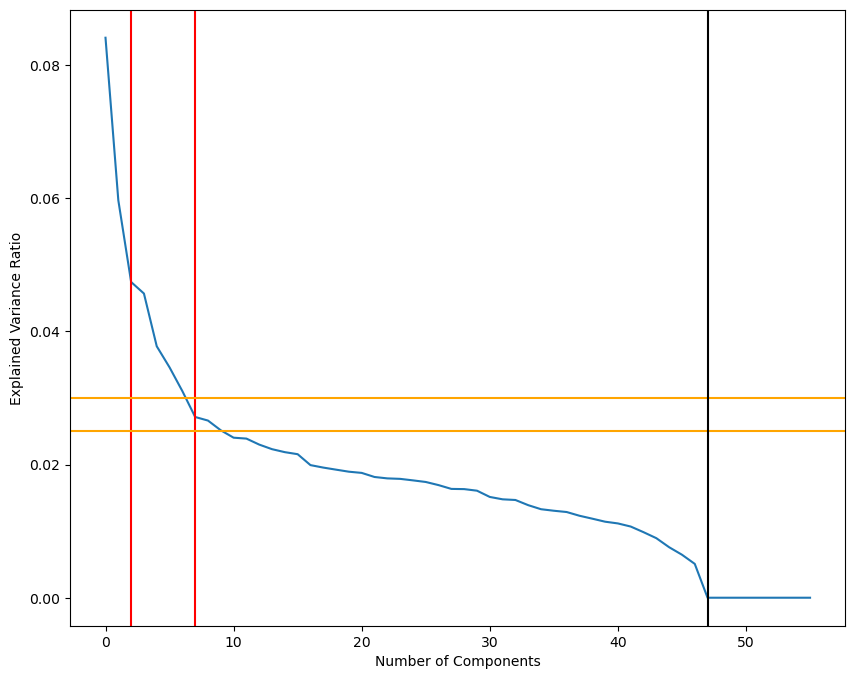

In [12]:
fig = plt.figure(figsize=(10,8))
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.axvline(x=7, c='red')
plt.axhline(y=0.03, c='orange')
plt.axhline(y=0.025, c='orange')
plt.axvline(x=47, c='black')
plt.show();

Elbow for this graphs occurs at ~ 7 components, variance ratio somewhere between 0.025 and 0.03. Components past 46 offer no variance.

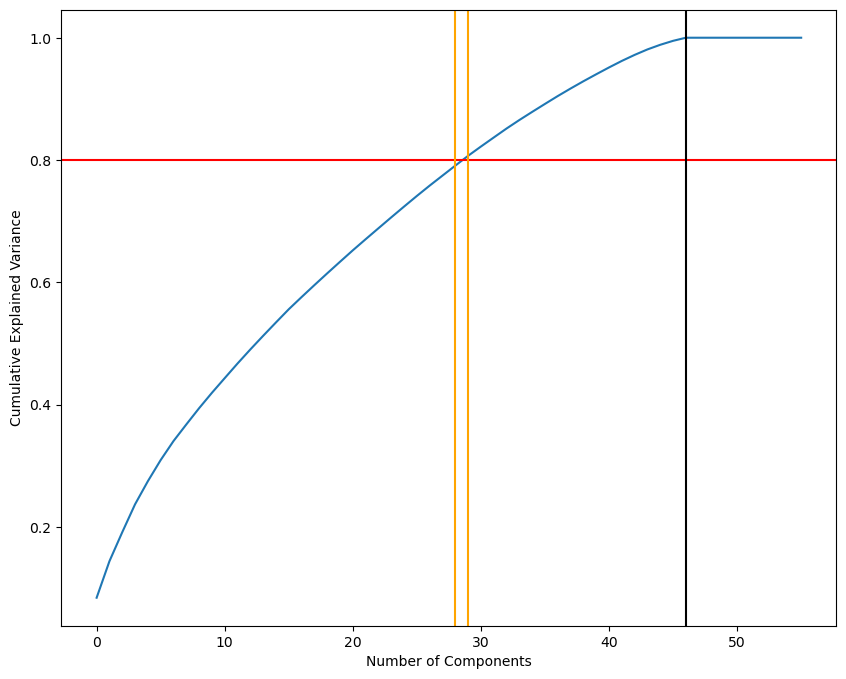

In [13]:
figure = plt.figure(figsize=(10,8))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.8, c='red')
plt.axvline(x=28, c='orange')
plt.axvline(x=29, c='orange')
plt.axvline(x=46, c='black')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.show();

80% of cumulative variance is explained by ~29 components. 100% of cumulative variance explained by 46 components.

With these results, I will move forward with a PCA object using 29 components.

In [14]:
pca = PCA(n_components = 29)
df_pca = pca.fit_transform(df_scaled)

Now we can look at the resulting components and get a sense of some groups that may have formed. I will write a function to do this so I can use it on multiple components, inlcuding in the nonvolunteer section, while saving code space.

I will look at the first 7 components, since that's where the elbow in our explained variance ratio graph occurred.

In [15]:
def get_weights(component_num, col_list):
    col_name = 'PC_'+str(component_num + 1)
    
    pca_weights = pd.DataFrame(
        pca.components_[component_num].T,  
        index=col_list,
        columns=[col_name]
    )
    
    # Print the top 10 features associated with the principal component, sorted by absolute value of weight
    print("Top positive:")
    print(pca_weights.sort_values(by=col_name, ascending=False).head(10))
    print("\nTop negative:")
    print(pca_weights.sort_values(by=col_name, ascending=True).head(10))
    print('----------------------------------------------------------')
    
    return pca_weights

In [16]:
col_list = df.columns

In [17]:
for pc in range(7):
    get_weights(pc, col_list)

Top positive:
                      PC_1
voterstatus_Yes   0.276473
age_encoded       0.255863
hetenure_Owned    0.245084
ntalk_encoded     0.224342
nissues_encoded   0.217398
favors_encoded    0.202352
news_encoded      0.183634
ffissues_encoded  0.182883
donate_Yes        0.180291
contact_Yes       0.178578

Top negative:
                              PC_1
hetenure_Rented          -0.245826
voterstatus_No           -0.240292
pemaritl_NEVER MARRIED   -0.213978
citizen_type_Non         -0.152796
voterstatus_NA           -0.122321
work_status_Employed     -0.121054
simrace_Black            -0.104588
simrace_Asian            -0.100702
citizen_type_Naturalized -0.073065
hrnumhou                 -0.052224
----------------------------------------------------------
Top positive:
                              PC_2
work_status_Employed      0.379303
hhincome_encoded          0.359455
hrnumhou                  0.280860
pemaritl_MARRIED          0.254981
ed_level_encoded          0.213600
hubus_

Let's tabulate this information to be easier to read:

| Component_Num | Positively-Pointed Features | Negatively-Pointed Features |
| ------------- | --------------------------- | --------------------------- |
| 1 | local voter, age, homeowner, interactions w/ neighbors, news consumption, donates non-politically, contacts politicians | renter, inelligible or non-local voter, never married, non-citizen or naturalized, employed, black or asian, household size |
| 2 | employed, income, married, education level, business owner, lives in a house, asian, homeowner, naturalized | not working, age, widowed, disabled, lives in mobile home, divorced, citizen, metro/non-metro, renter, veteran |
| 3 | citizen, white, homeowner, midwestern, married, metro/non-metro, non-local voter, household size, hispanic/non-hispanic, income | asian or black, naturalized or non-citizen, talking w/ neighbors/family/friends about issues, sharing views online, engages with local issues |
| 4 | citizen, never married or divorced, renter, employed, talking w/ family/friends about issues, participated in a boycott, contacts politicians, sharing views online, local voter | married, homeowner, naturalized or non-citizen, not working, asian, age, household size, inelligible or non-local voter |
| 5 | lives in a house, local voter, education level, age, not working, news consumption, hispanic/non-hispanic, widowed, black or asian | lives in a mobile home, interactions with neighbors, engages with local issues, household size, non-local voter, metro/non-metro, business owner, white |
| 6 | lives in a house, white, interactions with neighbors, non-local voter, renter, midwestern, engages with local issues, talking with family/friends | lives in a mobile home, black or asian, local voter, southern, homeowner, education level, hispanic/non-hispanic, naturalized, donates politically |
| 7 | southern, black, interactions with neighbors, hispanic/non-hispanic, citizen, engages with local issues, lives in a house, non-local voter | western or northeastern, white, participated in a boycott, lives in a mobile home, naturalized or non-citizen, local voter, contacts politicians, renter |

### Clustering

In [18]:
clusters = range (1, 20)
scores = []

for c in clusters:
    km_model = KMeans(n_clusters = c, random_state = 42)
    km_model.fit(df_pca)
    
    scores.append(km_model.score(df_pca))

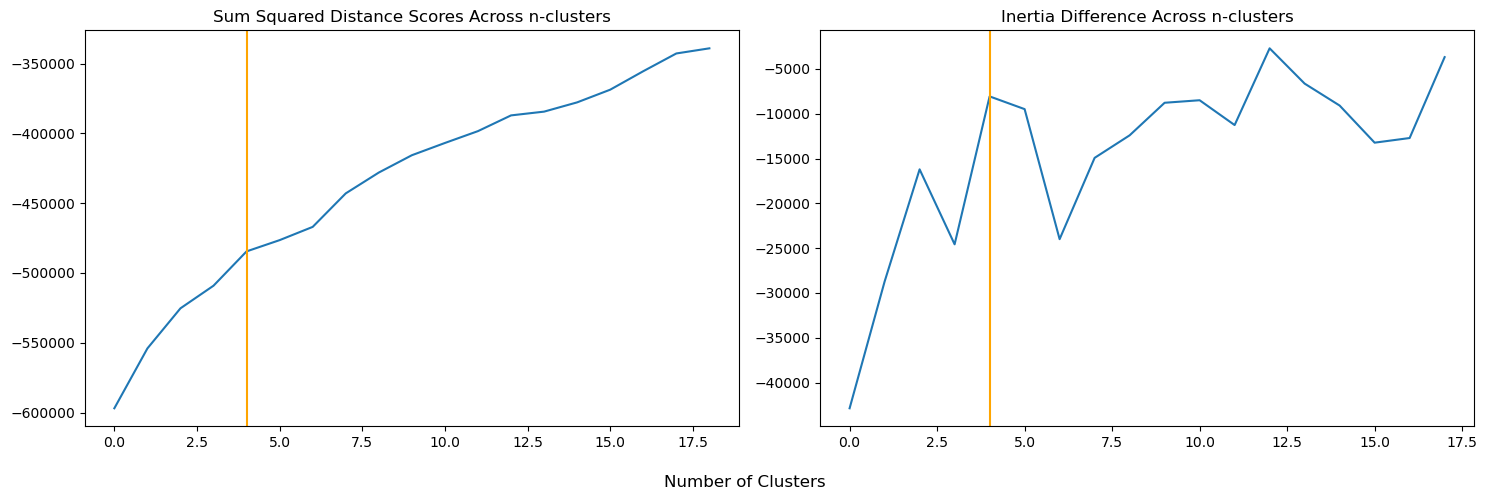

In [19]:
score_diff = []

for s in range(len(scores) - 1):
    score_diff.append(scores[s] - scores[s+1])
    
fig, (ax, bx) = plt.subplots(1,2, figsize=(15,5))
fig.supxlabel('Number of Clusters')
ax.set_title('Sum Squared Distance Scores Across n-clusters')
bx.set_title('Inertia Difference Across n-clusters')
ax.plot(scores)
bx.plot(score_diff)
ax.axvline(x=4, c='orange')
bx.axvline(x=4, c='orange')
plt.tight_layout()
plt.show()



There's a bit of an elbow at 4 clusters on the sum squared distance scores plot but it is not a dramatic plot by any means. The inertia plot is chaotic, but somewhere in the realm of 3-4 clusters seems to be a general inflection point. We'll move forward with 4 clusters.

In [20]:
km_model = KMeans(n_clusters=4)
volunteers = km_model.fit_predict(df_pca)